<a href="https://colab.research.google.com/github/MiguelDS021/Projeto-Regressa-Veiculos/blob/main/Projeto_Regress%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projeto Previsão de Preços de Carros**

Prevendo preços de carros fazendo o uso de métricas de regressão linear.

Link: https://archive.ics.uci.edu/dataset/10/automobile

### Fase 1: Importando Bibliotecas e dados.

Aqui vamos importar todas as bibliotecas e o dataset.

* Pandas: manipulação

* Matplotlib: gráficos

* Numpy: cálculos

* Scikit-Learn: modelagem



In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [139]:
df = pd.read_csv("https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DA0101EN/auto.csv", na_values="?" ,header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [140]:
## O dataset não possui cabeçalho, sendo assim, os nomes foram atribuidos com base na documentação
df.columns = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration", "num-of-doors",
           "body-style", "drive-wheels", "engine-location", "wheel-base", "length", "width",
           "height", "curb-weight", "engine-type", "num-of-cylinders", "engine-size", "fuel-system",
           "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

### Fase 2: Limpeza dos Dados

Aqui será feita toda limpeza do dataset.

* Visualizar o tamanho da tabela

* Buscar por nulos e outliers

* Visualizar duplicatas

* Usar estatística descritiva

Após a análise dos valore do dataset, Houve o tratamento de valores nulos, onde esses valores estavão com sinal de interrogação '?', fazendo com que os valores de algumas tabelas fossem object.

Por conta disso, retiramos 4 linhas da coluna price por conta dos nulos. Essa decisão foi tomada pelo fato do seguimento da regra de não poder imputar a variável alvo.

Para finalizar, preenchemos as colunas numéricas utilizando a mediana e colunas categóricas a moda.

In [97]:
df.shape

(205, 26)

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [99]:
df = df.dropna(subset=["price"])

In [100]:
df.shape

(201, 26)

In [101]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,201.000000,164.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,197.000000,201.000000,199.000000,199.000000,201.000000,201.000000,201.000000
mean,0.840796,122.000000,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330711,3.256904,10.164279,103.396985,5117.587940,25.179104,30.686567,13207.129353
std,1.254802,35.442168,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.270793,0.319256,4.004965,37.553843,480.521824,6.423220,6.815150,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


In [102]:
mediana_bore = df['bore'].median()
df['bore'] = df['bore'].fillna(mediana_bore)

In [103]:
lista_coluna = ['stroke', 'horsepower', 'peak-rpm', 'normalized-losses']

for coluna in lista_coluna:
  mediana = df[coluna].median()
  df[coluna] = df[coluna].fillna(mediana)

In [104]:
moda = df['num-of-doors'].mode()[0]
df['num-of-doors'] = df['num-of-doors'].fillna(moda)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    float64
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non-null

In [106]:
df.duplicated().sum()

np.int64(0)

### Fase 3: Outliers

Nesta fase, ocorreu a visualização de outliers no dataset.
Depois de todo o processo de investigação, conclui-se que, na verdade, os 14 outliers encontrados na tabela price, eram carros de marca de luxo (BMW, Jaguar, Porsche, Mercedes-Benz).

In [107]:
pq_preco = df['price'].quantile(0.25)
tq_preco = df['price'].quantile(0.75)
iqr_preco = tq_preco - pq_preco
ls_preco = tq_preco + 1.5 * iqr_preco
li_preco = pq_preco - 1.5 * iqr_preco

outliers_preco = df[~df['price'].between(li_preco, ls_preco)]
normais_preco = df[df['price'].between(li_preco, ls_preco)]

In [108]:
normais_preco

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


In [109]:
outliers_preco

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
15,0,115.0,bmw,gas,std,four,sedan,rwd,front,103.5,...,209,mpfi,3.62,3.39,8.0,182.0,5400.0,16,22,30760.0
16,0,115.0,bmw,gas,std,two,sedan,rwd,front,103.5,...,209,mpfi,3.62,3.39,8.0,182.0,5400.0,16,22,41315.0
17,0,115.0,bmw,gas,std,four,sedan,rwd,front,110.0,...,209,mpfi,3.62,3.39,8.0,182.0,5400.0,15,20,36880.0
47,0,145.0,jaguar,gas,std,four,sedan,rwd,front,113.0,...,258,mpfi,3.63,4.17,8.1,176.0,4750.0,15,19,32250.0
48,0,115.0,jaguar,gas,std,four,sedan,rwd,front,113.0,...,258,mpfi,3.63,4.17,8.1,176.0,4750.0,15,19,35550.0
49,0,115.0,jaguar,gas,std,two,sedan,rwd,front,102.0,...,326,mpfi,3.54,2.76,11.5,262.0,5000.0,13,17,36000.0
70,-1,93.0,mercedes-benz,diesel,turbo,four,sedan,rwd,front,115.6,...,183,idi,3.58,3.64,21.5,123.0,4350.0,22,25,31600.0
71,-1,115.0,mercedes-benz,gas,std,four,sedan,rwd,front,115.6,...,234,mpfi,3.46,3.10,8.3,155.0,4750.0,16,18,34184.0
72,3,142.0,mercedes-benz,gas,std,two,convertible,rwd,front,96.6,...,234,mpfi,3.46,3.10,8.3,155.0,4750.0,16,18,35056.0
73,0,115.0,mercedes-benz,gas,std,four,sedan,rwd,front,120.9,...,308,mpfi,3.80,3.35,8.0,184.0,4500.0,14,16,40960.0


In [110]:
outliers_preco.shape[0]

14

In [111]:
print(outliers_preco['make'])

15               bmw
16               bmw
17               bmw
47            jaguar
48            jaguar
49            jaguar
70     mercedes-benz
71     mercedes-benz
72     mercedes-benz
73     mercedes-benz
74     mercedes-benz
126          porsche
127          porsche
128          porsche
Name: make, dtype: object


### Fase 4: Análise Exploratória e Correlação.

Nesta fase, foram abordados as seguintes idéias para a análise:

* Observar gráficamente a relação de horsepower com price
* Elaborar uma tabela de correlação das características com o alvo

Com o gráfico da relação entre as duas colunas, podemos ver uma forte tendência positiva, com o diagnóstico de quanto mais cavalos/potência o carro obtem, maior será seu preço.

Já, com a tabela e a análise de correlação, vale destacar uma intensa ligação das tabelas (engine-size, curb-weight, horsepower) e uma baixa ligação entre (compression-ratio, peak-rpm).

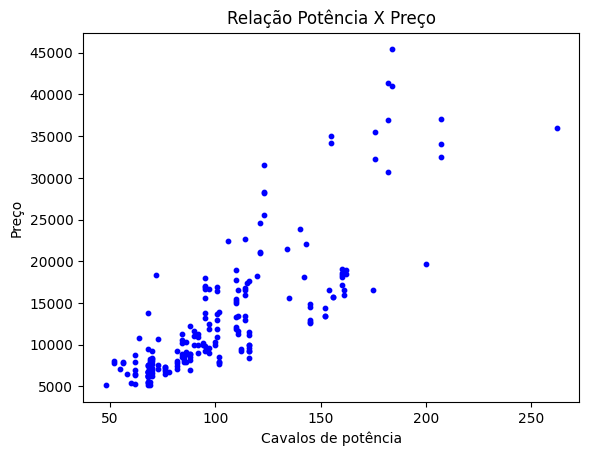

In [112]:
plt.scatter(x=df["horsepower"], y=df["price"], s=10, c='Blue')
plt.title("Relação Potência X Preço")
plt.xlabel("Cavalos de potência")
plt.ylabel("Preço")
plt.show()

In [113]:
df.corr(numeric_only=True)['price']

,price
symboling,-0.082391
normalized-losses,0.094366
wheel-base,0.584642
length,0.690628
width,0.751265
height,0.135486
curb-weight,0.834415
engine-size,0.872335
bore,0.543158
stroke,0.082209


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    float64
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non-null

In [115]:
features_numericas = ["engine-size", "curb-weight", "horsepower", "width",
                      "highway-mpg", "city-mpg", "bore"]

In [116]:
df[features_numericas].corr(numeric_only=True)

,engine-size,curb-weight,horsepower,width,highway-mpg,city-mpg,bore
engine-size,1.000000,0.849072,0.822167,0.729436,-0.679571,-0.650546,0.574504
curb-weight,0.849072,1.000000,0.757961,0.866201,-0.794889,-0.749543,0.644434
horsepower,0.822167,0.757961,1.000000,0.614146,-0.804490,-0.821171,0.565324
width,0.729436,0.866201,0.614146,1.000000,-0.680635,-0.633531,0.544986
highway-mpg,-0.679571,-0.794889,-0.804490,-0.680635,1.000000,0.972044,-0.589613
city-mpg,-0.650546,-0.749543,-0.821171,-0.633531,0.972044,1.000000,-0.580059
bore,0.574504,0.644434,0.565324,0.544986,-0.589613,-0.580059,1.000000


### Fase 5: Feature Engineering

Nesta etapa, preparamos os dados mudando seu tipo primitivo para se adequar ao modelo. Foram utilizados:

* OneHotEncoder
* StandardScaler

Após interpretação da tabela de correlação, foi decidido a retirada das features numéricas curb-weight e city-mpg, por conta da sua multicolinearidade com outras tabelas, fazendo com que o modelo possa ter uma duplicata em seu aprendizado.
Assim como a não optação da colunas make, engine-type e num-of-cylinders para features categóricas, para o aprendizado do modelo de regressão.

Explicando os motivos do uso de OneHotEncoder e StandardScaler:

OHE: utilizado por conta da features categóricas se tratar de variáveis qualitativas nominais, onde não possuem uma questão de ordem entre si.

SS: aplicado pelo fato da sua padronização de valores numéricos para média 0, desvio padrão 1 e sua melhor robustez a outliers.



In [117]:
features_numericas = ["engine-size", "horsepower", "width", "highway-mpg", "bore"]
features_categoricas = ["fuel-type", "num-of-doors", "body-style", "drive-wheels", "engine-location"]

In [118]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)


In [119]:
dados_codificados = encoder.fit_transform(df[features_categoricas])
print(dados_codificados)
dados_codificados.shape

[[0. 1. 0. ... 1. 1. 0.]
 [0. 1. 0. ... 1. 1. 0.]
 [0. 1. 0. ... 1. 1. 0.]
 ...
 [0. 1. 1. ... 1. 1. 0.]
 [1. 0. 1. ... 1. 1. 0.]
 [0. 1. 1. ... 1. 1. 0.]]


(201, 14)

In [120]:
encoder.get_feature_names_out()

array(['fuel-type_diesel', 'fuel-type_gas', 'num-of-doors_four',
       'num-of-doors_two', 'body-style_convertible', 'body-style_hardtop',
       'body-style_hatchback', 'body-style_sedan', 'body-style_wagon',
       'drive-wheels_4wd', 'drive-wheels_fwd', 'drive-wheels_rwd',
       'engine-location_front', 'engine-location_rear'], dtype=object)

In [121]:
df_categoricas = pd.DataFrame(dados_codificados, columns=encoder.get_feature_names_out())
df_categoricas

,fuel-type_diesel,fuel-type_gas,num-of-doors_four,num-of-doors_two,body-style_convertible,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon,drive-wheels_4wd,drive-wheels_fwd,drive-wheels_rwd,engine-location_front,engine-location_rear
0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
197,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
198,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
199,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [122]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

dado_escala = scaler.fit_transform(df[features_numericas])
print(dado_escala)

[[ 0.07538912  0.20617449 -0.85346024 -0.54228772  0.52240521]
 [ 0.07538912  0.20617449 -0.85346024 -0.54228772  0.52240521]
 [ 0.60623417  1.35955063 -0.18559675 -0.689386   -2.43175163]
 ...
 [ 1.1129499   0.82309661  1.43635744 -1.13068086  0.93374351]
 [ 0.43732893  0.07206099  1.43635744 -0.54228772 -1.19773674]
 [ 0.34081165  0.28664259  1.43635744 -0.83648429  1.68163132]]


In [123]:
df_numericas = pd.DataFrame(dado_escala, columns=features_numericas)
df_numericas

,engine-size,horsepower,width,highway-mpg,bore
0,0.075389,0.206174,-0.853460,-0.542288,0.522405
1,0.075389,0.206174,-0.853460,-0.542288,0.522405
2,0.606234,1.359551,-0.185597,-0.689386,-2.431752
3,-0.431327,-0.035230,0.148335,-0.100993,-0.524638
4,0.220165,0.313465,0.243744,-1.277779,-0.524638
...,...,...,...,...,...
196,0.340812,0.286643,1.436357,-0.395189,1.681631
197,0.340812,1.520487,1.388653,-0.836484,1.681631
198,1.112950,0.823097,1.436357,-1.130681,0.933744
199,0.437329,0.072061,1.436357,-0.542288,-1.197737


In [124]:
df_modelo = pd.concat([df_numericas, df_categoricas], axis=1)
df_modelo.head()

,engine-size,horsepower,width,highway-mpg,bore,fuel-type_diesel,fuel-type_gas,num-of-doors_four,num-of-doors_two,body-style_convertible,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon,drive-wheels_4wd,drive-wheels_fwd,drive-wheels_rwd,engine-location_front,engine-location_rear
0,0.075389,0.206174,-0.853460,-0.542288,0.522405,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.075389,0.206174,-0.853460,-0.542288,0.522405,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.606234,1.359551,-0.185597,-0.689386,-2.431752,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,-0.431327,-0.035230,0.148335,-0.100993,-0.524638,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.220165,0.313465,0.243744,-1.277779,-0.524638,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


### Fase 6: Modelo.

Nesta etapa, houve a preparação dos valores dos parâmetros X e y, fazendo uma boa divisão entre treino e teste para evitar overfitting.
A escolha do modelo de Regressão Linear se dá ao fato de ser simples e de fácil interpretação.

In [125]:
df = df.reset_index(drop=True)

In [126]:
df_modelo['price'] = df['price']

In [127]:
from sklearn.model_selection import train_test_split
X = df_modelo.drop(['price'], axis=1)
y = df_modelo['price']

In [128]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0, test_size=0.2)

In [129]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

### Fase 7 (Final): Avaliação e Conclusão.

Para a finalização do projeto, foi realizado os cálculos pelas seguintes métricas:

* Erro Médio Absoluto (MAE)
* Raiz do Erro Quadrático Médio (RMSE)
* Coeficiente de Determinação (R²)

Com MAE, foi adquirido o valor de 1968.92, aroximadamente 2.000 dólares, indicando que o modelo erra o preço de um carro por aproximadamente 2.000 dólares.

Com RMSE, obtivemos o valor de 2744.64, para distância média que as previsões estarão do alvo, onde esse número se da por conta das marcas de luxo que foram mantidas no dataset.

Com R², descobrimos o valor de 0.9006, aproximadamente 0.90, o que significa que 90% da variação de preço é explicado pelo modelo.

Com isso, finalizamos este projeto, podedo dar continuidade para testar outros modelos e fazer validações cruzadas.

In [130]:
resultado = modelo.predict(X_test)

In [131]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [132]:
MAE = mean_absolute_error(y_test, resultado)
MSE = mean_squared_error(y_test, resultado)
R2 = r2_score(y_test, resultado)
RMSE = np.sqrt(MSE)

In [133]:
print(RMSE, MAE, R2)

2744.6352145540554 1968.9214458655738 0.9005807912810182


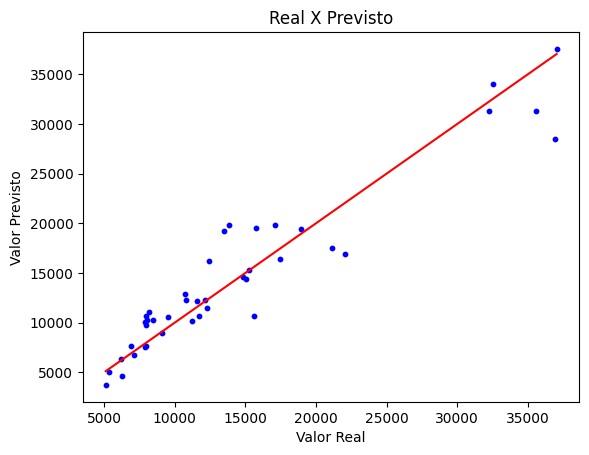

In [136]:
plt.scatter(x=y_test, y=resultado, s=10, c='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.title('Real X Previsto')
plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto')
plt.show()